# Sarsa 算法求解网格世界

使用 **Sarsa (State-Action-Reward-State-Action)** —— 一种在线策略 (on-policy) 的时序差分 (TD) 学习方法，对带陷阱的 5×5 网格世界进行求解。

## 核心思路
- 以 ε-贪心策略采样数据，生成轨迹
- 针对每条轨迹的每个时间步，使用 $(s, a, r, s', a')$ 五元组更新行为值函数
- 更新公式：$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]$

## 与原程序的差异与修正
| 原程序错误 | 修正 |
|-----------|------|
| `env.step()` 返回 3 个值却解包 4 个 | 改为 `s_, r, done = env.step(action)` |
| `SarsaTable(RL)` 在 `RL` 定义前使用 | 先定义 `RL` 基类，再定义 `SarsaTable` |
| `q_table.ix` 已废弃 | 改用 `q_table.loc` |
| `get_policy()` 依赖全局 `env` | 将 `env` 作为参数传入 |
| `env.render_by_policy_new()` 不存在 | 使用 `maze_draft.py` 中的 `render_policy()` |
| `__init__` 参数名不一致 | 统一使用 `actions` |
| `RL` 变量覆盖 `RL` 类 | 使用 `agent` 变量名持有实例 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from ReferenceCodes.Maze.draft_maze import MazeEnv, plot_learning_curve, plot_q_heatmap

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
class RL:
    """强化学习基类 —— 维护 Q 表并提供 ε-贪心策略选择。"""

    def __init__(self, actions, learning_rate=0.01, reward_decay=0.9, e_greedy=0.9):
        self.actions = actions
        self.lr = learning_rate
        self.gamma = reward_decay
        self.epsilon = e_greedy
        self.q_table = pd.DataFrame(columns=self.actions, dtype=np.float64)

    def check_state_exist(self, state):
        """若状态不在 Q 表中，则添加该状态（所有 Q 值初始化为 0）。"""
        if state not in self.q_table.index:
            new_row = pd.Series(
                [0.0] * len(self.actions),
                index=self.q_table.columns,
                name=state,
            )
            self.q_table = pd.concat([self.q_table, new_row.to_frame().T])

    def choose_action(self, observation):
        """ε-贪心策略选择动作。
        以概率 ε 选择当前最优动作，否则随机探索。
        当多个动作同为最优时，随机从中选取一个。
        """
        self.check_state_exist(observation)

        if np.random.rand() < self.epsilon:
            state_action = self.q_table.loc[observation, :]
            # 随机排列索引以避免确定性偏向，然后取最大值
            state_action = state_action.sample(frac=1)
            action = state_action.idxmax()
        else:
            action = np.random.choice(self.actions)
        return action

    def learn(self, *args):
        pass

In [3]:
class SarsaTable(RL):
    """Sarsa 在线策略 TD 学习算法。

    更新规则: Q(s,a) ← Q(s,a) + α [r + γ·Q(s',a') − Q(s,a)]
    其中 a' 由当前策略（ε-贪心）在状态 s' 下选出，
    这使得 Sarsa 对探索过程中的风险更为敏感。
    """

    def __init__(self, actions, learning_rate=0.01, reward_decay=0.9, e_greedy=0.9):
        super().__init__(actions, learning_rate, reward_decay, e_greedy)

    def learn(self, s, a, r, s_, a_):
        """使用 (s, a, r, s', a') 五元组更新 Q 表。"""
        self.check_state_exist(s)
        self.check_state_exist(s_)

        q_predict = self.q_table.loc[s, a]

        if s_ != 'terminal':
            q_target = r + self.gamma * self.q_table.loc[s_, a_]
        else:
            q_target = r

        self.q_table.loc[s, a] += self.lr * (q_target - q_predict)

    @staticmethod
    def get_best_actions(q_table, state):
        """返回指定状态下 Q 值最大的所有动作列表。"""
        state_action = q_table.loc[state, :]
        max_val = state_action.max()
        best = [int(a) for a in state_action[state_action == max_val].index]
        best.sort()
        return tuple(best)

    @staticmethod
    def get_policy(q_table, env):
        """从 Q 表中提取贪心策略。

        Args:
            q_table: 训练好的 Q 表
            env: MazeEnv 实例，用于获取所有状态及终止状态信息

        Returns:
            dict: state -> best_action(s)
        """
        policy = {}
        for r in range(env.rows):
            for c in range(env.cols):
                state = (r, c)
                if state in env.terminal_states:
                    policy[state] = -1  # 终止状态
                    continue
                state_str = env.state_to_str(state)
                if state_str in q_table.index:
                    policy[state] = SarsaTable.get_best_actions(q_table, state_str)
                else:
                    policy[state] = (0, 1, 2, 3)  # 未知状态，均匀随机
        return policy

In [4]:
def train_sarsa(env, agent, episodes=500, verbose=True):
    """使用 Sarsa 算法训练智能体。

    Args:
        env: MazeEnv 环境
        agent: SarsaTable 智能体
        episodes: 训练轮数
        verbose: 是否打印中间结果

    Returns:
        rewards_history: 每轮的累积奖励
        steps_history: 每轮的步数
        success_history: 每轮是否成功 (1=找到宝藏, 0=落入陷阱)
    """
    rewards_history = []
    steps_history = []
    success_history = []

    for episode in range(episodes):
        s = env.reset()
        s_str = env.state_to_str(s)

        # 在状态 s 下选择动作 a（遵循 ε-贪心）
        a = agent.choose_action(s_str)

        total_reward = 0
        steps = 0

        while True:
            # 执行动作 a，观测 r, s'
            s_, r, done = env.step(a)
            s_str_ = env.state_to_str(s_) if not done else 'terminal'

            # 在状态 s' 下选择动作 a'（遵循 ε-贪心）
            a_ = agent.choose_action(s_str_) if not done else -1

            # Sarsa 更新：使用 (s, a, r, s', a')
            agent.learn(s_str, a, r, s_str_, a_)

            total_reward += r
            steps += 1

            if done:
                break

            s_str, a = s_str_, a_

        rewards_history.append(total_reward)
        steps_history.append(steps)
        success_history.append(1 if total_reward == 1 else 0)

        if verbose and (episode + 1) % 50 == 0:
            recent_success = np.mean(success_history[-50:]) * 100
            print(f"Episode {episode+1:4d}/{episodes} | "
                  f"Avg Reward: {np.mean(rewards_history[-50:]):.2f} | "
                  f"Success Rate: {recent_success:.0f}% | "
                  f"Avg Steps: {np.mean(steps_history[-50:]):.1f}")

    return rewards_history, steps_history, success_history

In [5]:
# 初始化环境和智能体
env = MazeEnv()
agent = SarsaTable(
    actions=list(range(env.n_actions)),
    learning_rate=0.1,
    reward_decay=0.9,
    e_greedy=0.9,
)

# 训练
rewards, steps, success = train_sarsa(env, agent, episodes=20000)

print(f"\n训练完成！最终 100 轮成功率: {np.mean(success[-100:]):.1%}")

Episode   50/20000 | Avg Reward: -0.36 | Success Rate: 32% | Avg Steps: 48.6
Episode  100/20000 | Avg Reward: 0.76 | Success Rate: 88% | Avg Steps: 11.6
Episode  150/20000 | Avg Reward: 0.56 | Success Rate: 78% | Avg Steps: 10.2
Episode  200/20000 | Avg Reward: 0.76 | Success Rate: 88% | Avg Steps: 6.3
Episode  250/20000 | Avg Reward: 0.80 | Success Rate: 90% | Avg Steps: 6.0
Episode  300/20000 | Avg Reward: 0.68 | Success Rate: 84% | Avg Steps: 12.3
Episode  350/20000 | Avg Reward: 0.64 | Success Rate: 82% | Avg Steps: 6.8
Episode  400/20000 | Avg Reward: 0.68 | Success Rate: 84% | Avg Steps: 7.5
Episode  450/20000 | Avg Reward: 0.72 | Success Rate: 86% | Avg Steps: 6.1
Episode  500/20000 | Avg Reward: 0.60 | Success Rate: 80% | Avg Steps: 6.2
Episode  550/20000 | Avg Reward: 0.56 | Success Rate: 78% | Avg Steps: 6.9
Episode  600/20000 | Avg Reward: 0.76 | Success Rate: 88% | Avg Steps: 6.5
Episode  650/20000 | Avg Reward: 0.84 | Success Rate: 92% | Avg Steps: 6.3
Episode  700/20000 |

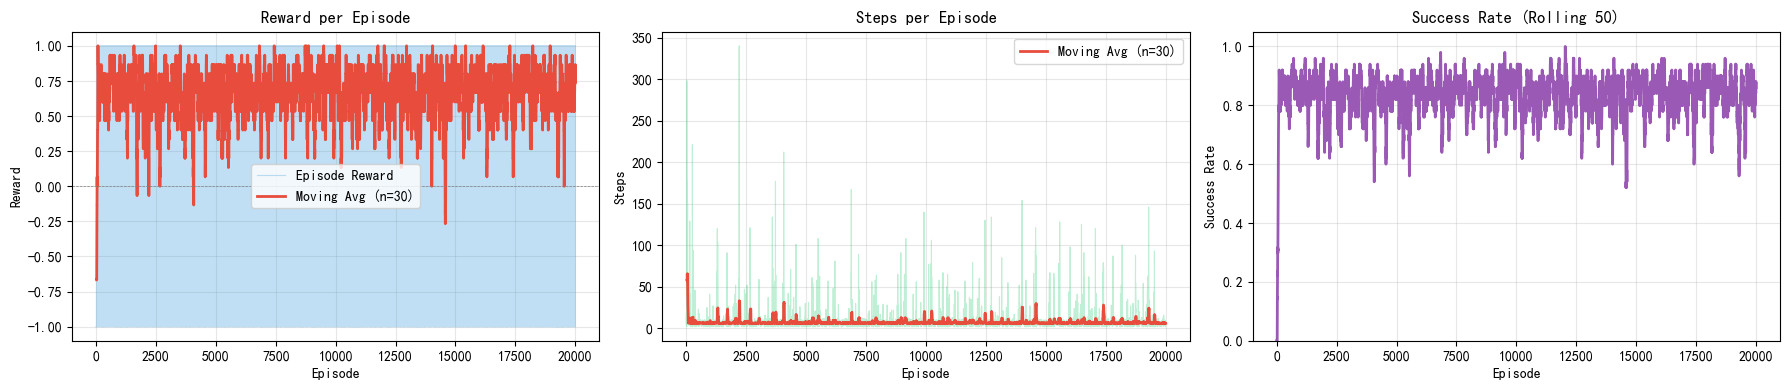

In [6]:
# ============================================================
# 可视化 1: 学习曲线
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

plot_learning_curve(rewards, window=30, title="Reward per Episode", ax=axes[0])

axes[1].plot(steps, alpha=0.3, color='#2ecc71', linewidth=0.8)
if len(steps) >= 30:
    smoothed = np.convolve(steps, np.ones(30)/30, mode='valid')
    axes[1].plot(range(29, len(steps)), smoothed, color='#e74c3c', linewidth=2, label='Moving Avg (n=30)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].set_title('Steps per Episode')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

success_rate = [np.mean(success[max(0,i-49):i+1]) for i in range(len(success))]
axes[2].plot(success_rate, color='#9b59b6', linewidth=2)
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Success Rate')
axes[2].set_title('Success Rate (Rolling 50)')
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

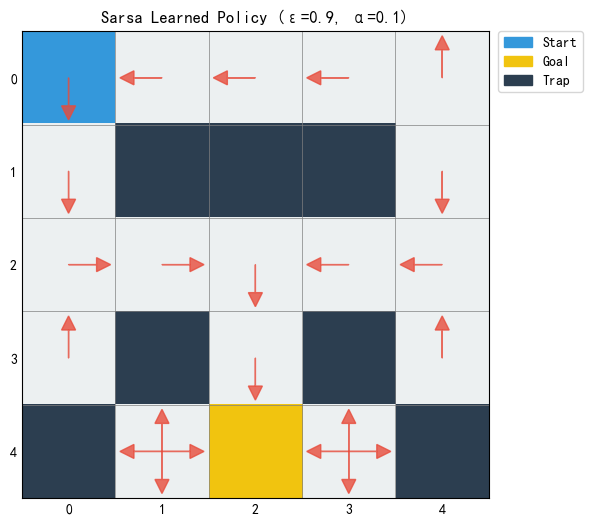

各状态最优动作:
 ↓     ←     ←     ←     ↑    
 ↓    [ H ] [ H ] [ H ]  ↓    
 →     →     ↓     ←     ←    
 ↑    [ H ]  ↓    [ H ]  ↑    
[ H ]  ↑↓←→ [ G ]  ↑↓←→ [ H ] 


In [7]:
# ============================================================
# 可视化 2: 最优策略展示
# ============================================================
policy = SarsaTable.get_policy(agent.q_table, env)

fig, ax = plt.subplots(figsize=(6, 6))
env.render_policy(policy, title="Sarsa Learned Policy (ε=0.9, α=0.1)", ax=ax)
plt.tight_layout()
plt.show()

print("各状态最优动作:")
arrows = {0: '↑', 1: '↓', 2: '←', 3: '→'}
for r in range(env.rows):
    line = ""
    for c in range(env.cols):
        state = (r, c)
        if state in env.terminal_states:
            if state == env.goal_state:
                line += "[ G ] "
            else:
                line += "[ H ] "
        elif state in policy:
            acts = policy[state]
            if acts == -1:
                line += "[ - ] "
            else:
                act_str = ''.join(arrows[a] for a in acts)
                line += f" {act_str:<4s} "
        else:
            line += "  ?    "
    print(line)

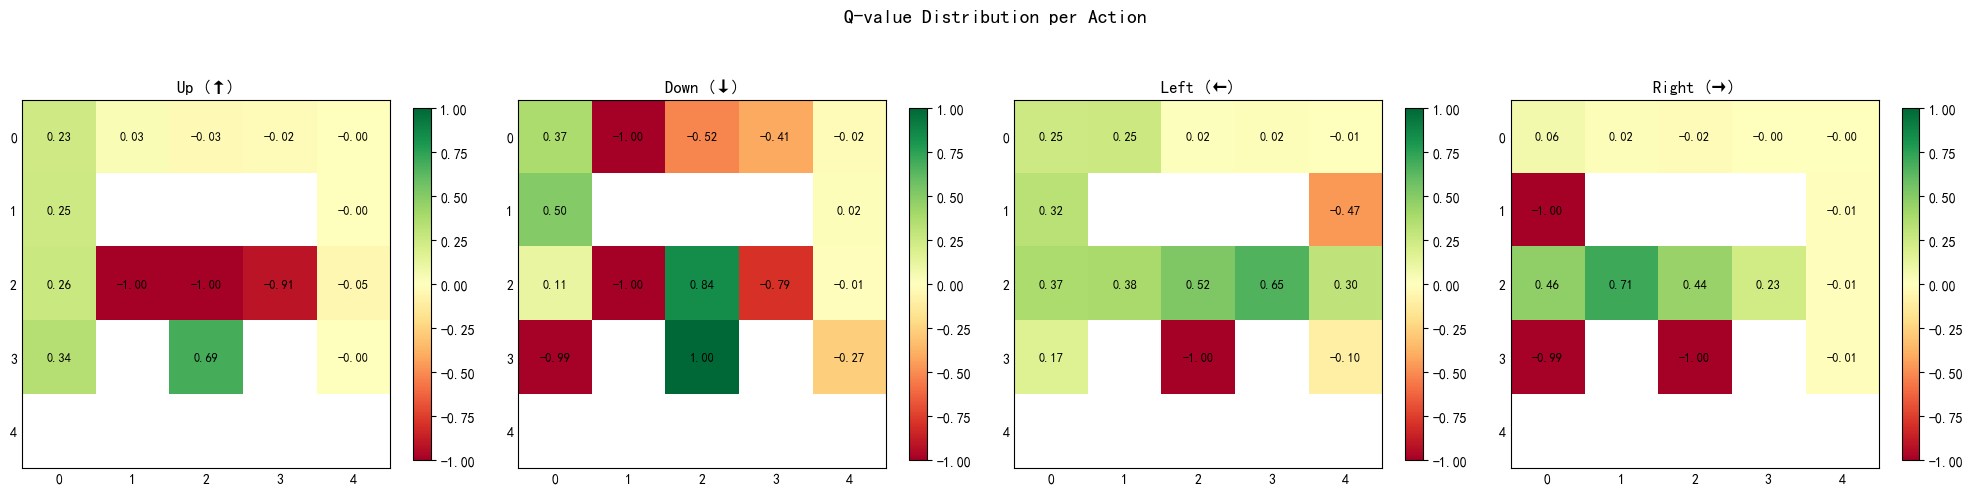

In [8]:
# ============================================================
# 可视化 3: Q 值热力图
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
action_names = ['Up (↑)', 'Down (↓)', 'Left (←)', 'Right (→)']

for a in range(4):
    q_grid = np.full((env.rows, env.cols), np.nan)
    for r in range(env.rows):
        for c in range(env.cols):
            state = (r, c)
            if state in env.terminal_states:
                continue
            state_str = env.state_to_str(state)
            if state_str in agent.q_table.index:
                q_grid[r, c] = agent.q_table.loc[state_str, a]

    im = axes[a].imshow(q_grid, cmap='RdYlGn', aspect='equal',
                        origin='upper', vmin=-1, vmax=1)
    for r in range(env.rows):
        for c in range(env.cols):
            if not np.isnan(q_grid[r, c]):
                axes[a].text(c, r, f"{q_grid[r,c]:.2f}",
                            ha='center', va='center', fontsize=9)
    axes[a].set_xticks(range(env.cols))
    axes[a].set_yticks(range(env.rows))
    axes[a].set_title(action_names[a])
    axes[a].tick_params(length=0)
    plt.colorbar(im, ax=axes[a], shrink=0.8)

plt.suptitle('Q-value Distribution per Action', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

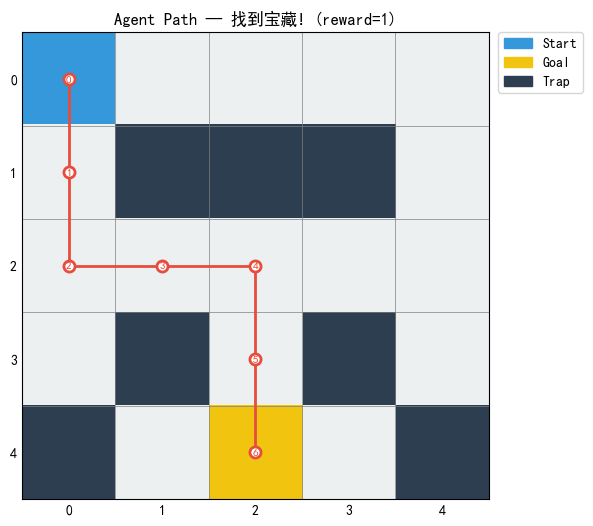

路径: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2)]
总奖励: 1, 步数: 6, 结果: 找到宝藏!


In [9]:
# ============================================================
# 可视化 4: 智能体走迷宫路径演示
# ============================================================
def run_agent(env, agent, max_steps=50):
    """使用训练好的智能体走一次迷宫，返回路径和结果。"""
    s = env.reset()
    path = [s]
    total_reward = 0

    for _ in range(max_steps):
        s_str = env.state_to_str(s)
        a = agent.choose_action(s_str)
        s_, r, done = env.step(a)
        path.append(s_)
        total_reward += r
        if done:
            break
        s = s_

    result = "找到宝藏!" if total_reward == 1 else ("落入陷阱" if total_reward == -1 else "达到最大步数")
    return path, total_reward, result


path, total_r, result = run_agent(env, agent)

fig, ax = plt.subplots(figsize=(6, 6))
env.render_path(path, title=f"Agent Path — {result} (reward={total_r})", ax=ax)
plt.tight_layout()
plt.show()

print(f"路径: {path}")
print(f"总奖励: {total_r}, 步数: {len(path)-1}, 结果: {result}")

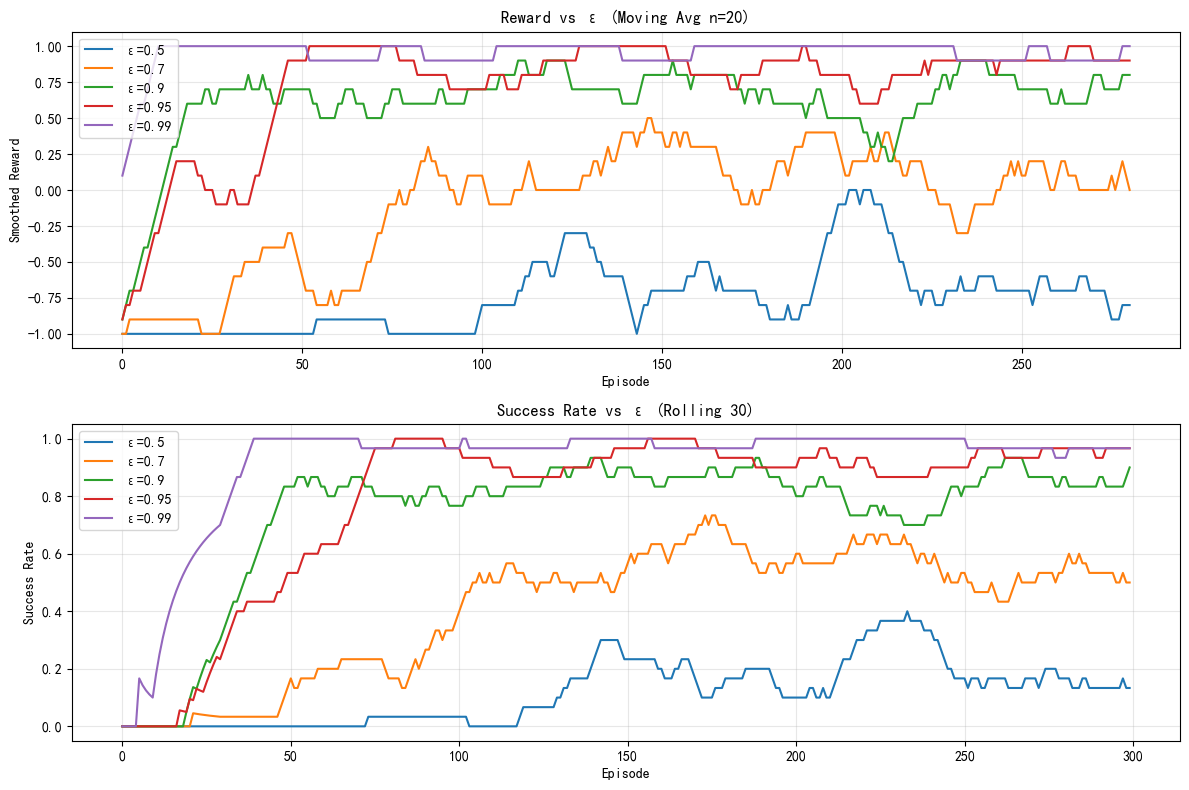

In [10]:
# ============================================================
# 可视化 5: ε 参数敏感性分析
# 对比不同 ε 值对学习效果的影响
# ============================================================
epsilons = [0.5, 0.7, 0.9, 0.95, 0.99]
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for eps in epsilons:
    env_test = MazeEnv()
    agent_test = SarsaTable(
        actions=list(range(env_test.n_actions)),
        learning_rate=0.1,
        reward_decay=0.9,
        e_greedy=eps,
    )
    r_hist, s_hist, succ_hist = train_sarsa(env_test, agent_test, episodes=300, verbose=False)

    smoothed_r = np.convolve(r_hist, np.ones(20)/20, mode='valid')
    axes[0].plot(smoothed_r, label=f'ε={eps}', linewidth=1.5)

    succ_rate = [np.mean(succ_hist[max(0,i-29):i+1]) for i in range(len(succ_hist))]
    axes[1].plot(succ_rate, label=f'ε={eps}', linewidth=1.5)

axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Smoothed Reward')
axes[0].set_title('Reward vs ε (Moving Avg n=20)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate')
axes[1].set_title('Success Rate vs ε (Rolling 30)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()